In [ ]:
from simple_foraging_env import SimpleForagingEnv, SimpleAgent, RandomAgent, GreedySwitchAgent
from opponent_model import OpponentModel
from q_agent import QLearningAgent, ReplayBuffer
from q_agent_classic import QLearningAgentClassic
from omg_args import OMGArgs
import transformers as t
import matplotlib.pyplot as plt
import os
import random
import time
from IPython.display import clear_output
from collections import deque
import torch
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.manifold import TSNE

In [ ]:
import q_agent
import q_agent_classic
from maps import *


map_layout = MAP_3
map_name = "MAP_3"

om_id = 0
classic_id = 0
# opponent_agent = GreedySwitchAgent(1)
opponent_agent = SimpleAgent(1)

device = "cuda" if torch.cuda.is_available() else "cpu"

env = SimpleForagingEnv(max_steps=100, map_layout=map_layout)

obs_sample = env.reset()[0]
H, W, F_dim = obs_sample.shape
NUM_ACTIONS = 4

args = OMGArgs(
  device=device,
  folder_id=0,
  batch_size=128,
  qnet_hidden=256,
  cnn_hidden=64,
  max_steps=50,
  tau_start=2.0,
  tau_end=0.05,
  state_shape=obs_sample.shape,
  H=H, W=W,
  action_dim=NUM_ACTIONS,
  d_model=64,
  nhead=4,
  num_encoder_layers=1,
  dim_feedforward=256,
  dropout=0.1,
)
# opponent_agent = QLearningAgentClassic(
#     env=env,
#     args=args
# )

inference_model = t.SpatialOpponentModel(args=args).to(args.device)
op_model = OpponentModel(model=inference_model, args=args)
q_agent = QLearningAgent(
    env=env,
    opponent_model=op_model,
    args=args
)
q_agent_classic = QLearningAgentClassic(
    env=env,
    args=args
)

opponent_name = opponent_agent.__class__.__name__

qnet_path = f'./models/{om_id}/om_qnet.pth'
om_path = f'./models/{om_id}/om_inference.pth'
classic_qnet_path = f'./models/{classic_id}/classic_qnet.pth'

q_agent.q.load_state_dict(torch.load(qnet_path, map_location=args.device))
q_agent.model.inference_model.load_state_dict(torch.load(om_path, map_location=args.device))
q_agent_classic.q.load_state_dict(torch.load(classic_qnet_path, map_location=args.device))

In [ ]:
# functions to run episodes with the agents, used for testing and evaluation

def run_om_episode(env, q_agent, opponent_agent, render=False):
  obs = env.reset()
  opponent_agent.reset()
  device = q_agent.args.device
  done = False
  ep_ret = 0.0
  opp_ret = 0.0
  ep_entropy = 0.0
  ep_kl_errors = []
  ep_spatial_errors = []
  ep_opp_rewards = []

  # History container for the Transformer
  history_len = q_agent.args.max_history_length
  rolling_feats = torch.zeros(
    (1, history_len, q_agent.args.d_model), device=device)
  rolling_actions = torch.zeros(
    (1, history_len), dtype=torch.long, device=device)
  rolling_mask = torch.zeros(
    (1, history_len), dtype=torch.bool, device=device)
  current_seq_len = 0

  for step in range(50):
    history = {
        "state_features": rolling_feats,
        "actions": rolling_actions,
        "mask": rolling_mask
      }

    a, g_map, step_entropy = q_agent.select_action(
      obs[0], history, eval=True)
    a_opponent, _, opp_heatmap = opponent_agent.select_action(
      obs[1], eval=True)
    actions = {0: a, 1: a_opponent}

    if render:
      # clear_output(wait=True)
      print(f"Step: {step} | Return: {ep_ret}")
      q_agent.heatmap_q_values(g_map, save=False)
      q_agent.heatmap_subgoal(g_map, save=False)
      time.sleep(0.2)
      env.render_from_obs(obs[0])
    
    if g_map.dim() == 2:
      g_map = g_map.unsqueeze(0)  # (1, H, W)

    # Convert to tensor (1, H, W) and move to device
    opp_heatmap = torch.from_numpy(opp_heatmap).unsqueeze(0).to(device)

    kl_error = q_agent.model.heatmap_kl_divergence(g_map, opp_heatmap)
    spatial_error = q_agent.model.top1_spatial_error(g_map, opp_heatmap)
    ep_kl_errors.append(kl_error)
    ep_spatial_errors.append(spatial_error)

    next_obs, reward, done, info = env.step(actions)

    state_tensor = torch.from_numpy(
      obs[0]).float().unsqueeze(0).to(device)
    with torch.no_grad():
      new_feat = q_agent.model.inference_model.get_features(
        state_tensor)  # (1, d_model)

    rolling_feats = torch.roll(rolling_feats, shifts=-1, dims=1)
    rolling_actions = torch.roll(rolling_actions, shifts=-1, dims=1)
    rolling_mask = torch.roll(rolling_mask, shifts=-1, dims=1)

    rolling_feats[:, -1, :] = new_feat
    rolling_actions[:, -1] = a_opponent

    if current_seq_len < history_len:
      current_seq_len += 1
      rolling_mask[:, -current_seq_len:] = True

    ep_ret += reward[0]
    opp_ret += reward[1]
    ep_opp_rewards.append(reward[1])
    obs = next_obs
    ep_entropy += step_entropy

    if done:
      break

  # Post-episode analysis to compute final metrics, for cases where opponent fails to get food
  kd_errors = []
  spatial_errors = []

  if reward[1] == 0 and reward[0] > 0:
    last_valid_step = len(ep_opp_rewards)
    for t in reversed(range(len(ep_opp_rewards))):
      if ep_opp_rewards[t] > 0:
        last_valid_step = t + 1
        break
    
    if last_valid_step > 0:
      kd_errors.extend(ep_kl_errors[:last_valid_step])
      spatial_errors.extend(ep_spatial_errors[:last_valid_step])
          
  else:
    # Normal ending (both got food, or time ran out)
    kd_errors.extend(ep_kl_errors)
    spatial_errors.extend(ep_spatial_errors)

  return {
    "return": ep_ret,
    "steps": step + 1,
    "opp_return": opp_ret,
    "avg_entropy": ep_entropy / (step + 1),
    "avg_kl_error": np.mean(kd_errors) if kd_errors else None,
    "avg_spatial_error": np.mean(spatial_errors) if spatial_errors else None
  }

def run_classic_episode(env, q_agent_classic, opponent_agent, render=False):
  obs = env.reset()
  opponent_agent.reset()
  done = False
  ep_ret = 0.0
  ep_entropy = 0.0

  for step in range(50):
    a, step_entropy = q_agent_classic.select_action(obs[0], eval=True)
    a_opponent, _, _ = opponent_agent.select_action(obs[1], eval=True)
    actions = {0: a, 1: a_opponent}

    if render:
      clear_output(wait=True)
      print(f"Step: {step} | Return: {ep_ret}")
      q_agent_classic.heatmap_q_values(save=False)
      time.sleep(0.2)
      env.render_from_obs(obs[0])

    next_obs, reward, done, info = env.step(actions)

    ep_ret += reward[0]
    obs = next_obs
    ep_entropy += step_entropy

    if done:
      break
  return {
    "return": ep_ret, 
    "steps": step + 1,
    "avg_entropy": ep_entropy / (step + 1)
  }

@torch.no_grad()
def visualize_final_memory_3d(model, x, history, target_map):
    """
    Runs a batch of data through the model, extracts the final_memory,
    and plots it using t-SNE, color-coded by the true goal location.
    """
    model.eval()
    device = model.args.device
    
    # To extract final_memory, we temporarily mimic the forward pass
    B, H, W, F_dim = x.shape
    x_feat = model.get_features(x).unsqueeze(1)
    
    hist_actions = history['actions']  # (B, T)
    hist_mask = history['mask']      # (B, T) True for valid tokens
    T = hist_actions.shape[1]

    hist_feat = history['state_features']  # (B, T, d_model)

    hist_action_feat = model.action_embedder(hist_actions)  # (B, T, d_model)

    hist_feat = hist_feat + hist_action_feat  # (B, T, d_model)

    # Prepend current state
    seq_feats = torch.cat([x_feat, hist_feat], dim=1)  # (B, 1 + T, d_model)

    # Index 0 current state x is always valid
    x_mask = torch.ones((B, 1), dtype=torch.bool, device=x.device)
    full_mask = torch.cat([x_mask, hist_mask], dim=1)  # (B, 1 + T)

    # Positional encoding
    seq_feats = seq_feats * np.sqrt(model.args.d_model)
    seq_feats = model.pos_encoder(seq_feats)

    # Transformer pass
    src_key_padding_mask = ~full_mask
    memory = model.transformer(
      seq_feats, src_key_padding_mask=src_key_padding_mask)

    # Extract summary and predict
    final_memory = memory[:, 0, :]
    
    final_memory_np = final_memory.cpu().numpy()
    
    true_goals_flat = [np.argmax(b.cpu().numpy()) for b in target_map]
    
    readable_goals = []
    for g in true_goals_flat:
        # Check if it's the "null" map (all zeros, meaning goal was dropped)
        # Using a sum check: if the max value is 0, there is no target.
        if target_map[len(readable_goals)].cpu().numpy().max() == 0:
             readable_goals.append("No Target / Ambiguous")
        else:
             r, c = g // W, g % W
             readable_goals.append(f"Food at ({r}, {c})")
             
    # 3. Run 3D t-SNE
    tsne = TSNE(n_components=3, perplexity=30, random_state=42)
    memory_3d = tsne.fit_transform(final_memory_np)
    
    # 4. Create a DataFrame for Plotly
    df = pd.DataFrame({
        't-SNE 1': memory_3d[:, 0],
        't-SNE 2': memory_3d[:, 1],
        't-SNE 3': memory_3d[:, 2],
        'Target Subgoal': readable_goals
    })
    
    # 5. Plot Interactive 3D Scatter
    fig = px.scatter_3d(
        df, x='t-SNE 1', y='t-SNE 2', z='t-SNE 3', 
        color='Target Subgoal',
        title="3D t-SNE of Transformer Belief State",
        opacity=0.8
    )
    
    # Make the dots a bit larger for readability
    fig.update_traces(marker=dict(size=5))
    
    # This renders the interactive widget directly in your Jupyter Notebook
    fig.show()

@torch.no_grad()
def visualize_final_memory_2d(model, x, history, target_map, filename="model_beliefs.png"):
    """
    Runs a batch of data through the model, extracts the final_memory,
    and plots it using t-SNE, color-coded by the true goal location.
    """
    model.eval()
    
    # 1. Forward Pass 
    B, H, W, F_dim = x.shape
    x_feat = model.get_features(x).unsqueeze(1)
    
    hist_actions = history['actions']
    hist_mask = history['mask']
    hist_feat = history['state_features']
    
    hist_action_feat = model.action_embedder(hist_actions)
    hist_feat = hist_feat + hist_action_feat
    
    seq_feats = torch.cat([x_feat, hist_feat], dim=1)
    
    x_mask = torch.ones((B, 1), dtype=torch.bool, device=x.device)
    full_mask = torch.cat([x_mask, hist_mask], dim=1)
    
    seq_feats = seq_feats * np.sqrt(model.args.d_model)
    seq_feats = model.pos_encoder(seq_feats)
    
    src_key_padding_mask = ~full_mask
    memory = model.transformer(seq_feats, src_key_padding_mask=src_key_padding_mask)
    
    final_memory = memory[:, 0, :]
    final_memory_np = final_memory.cpu().numpy()
    
    # 2. Map Flattened Indices to Readable (Row, Col) Coordinates
    true_goals_flat = [np.argmax(b.cpu().numpy()) for b in target_map]
    
    readable_goals = []
    for i, g in enumerate(true_goals_flat):
        if target_map[i].cpu().numpy().max() == 0:
             readable_goals.append("No Target / Ambiguous")
        else:
             r, c = g // W, g % W
             readable_goals.append(f"Food at ({r}, {c})")
             
    # 3. Run 2D t-SNE
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    memory_2d = tsne.fit_transform(final_memory_np)
    
    # 4. Plotting with Matplotlib
    plt.figure(figsize=(10, 7))
    
    # Get unique labels and assign distinct colors using a colormap
    unique_labels = sorted(list(set(readable_goals)))
    cmap = plt.get_cmap('tab10') # Good discrete colormap
    colors = [cmap(i % 10) for i in range(len(unique_labels))]
    color_map = dict(zip(unique_labels, colors))
    
    # Scatter plot grouped by category to auto-generate a discrete legend
    for label in unique_labels:
        # Find all indices matching this label
        idx = [i for i, l in enumerate(readable_goals) if l == label]
        plt.scatter(memory_2d[idx, 0], memory_2d[idx, 1], 
                    c=[color_map[label]], label=label, alpha=0.8, s=60, edgecolors='w', linewidths=0.5)
    
    plt.title("2D t-SNE of Transformer Belief State", fontsize=16, pad=15)
    plt.xlabel("t-SNE Dimension 1", fontsize=12)
    plt.ylabel("t-SNE Dimension 2", fontsize=12)
    
    # Place legend outside the plot so it doesn't cover data points
    plt.legend(title="True Subgoal Location", title_fontsize='13', fontsize='11', 
               bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
               
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()

    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


def collect_data(env, agent0, agent1, num_episodes=1000):
  master_dataset = []
  for _ in range(num_episodes):
    obs = env.reset()
    agent0.reset()
    agent1.reset()

    episode_transitions = []
    history_len = agent0.args.max_history_length
    rolling_feats = torch.zeros(
      (1, history_len, agent0.args.d_model), device=agent0.args.device)
    rolling_actions = torch.zeros(
      (1, history_len), dtype=torch.long, device=agent0.args.device)
    rolling_mask = torch.zeros(
      (1, history_len), dtype=torch.bool, device=agent0.args.device)
    current_seq_len = 0

    H, W, _ = obs[0].shape

    for step in range(args.max_steps):
      history_gpu = {
        "state_features": rolling_feats,
        "actions": rolling_actions,
        "mask": rolling_mask
      }

      # Both agents act using pure heuristics
      a_0, _, _ = agent0.select_action(obs[0], history_gpu, eval=True)
      a_1, _, true_opp_heatmap = agent1.select_action(obs[1])
      actions = {0: a_0, 1: a_1}

      next_obs, reward, done, info = env.step(actions)

      history_cpu = {
          "state_features": rolling_feats.cpu().numpy(),
          "actions": rolling_actions.cpu().numpy(),
          "mask": rolling_mask.cpu().numpy()
      }
      transition = {
          "state": obs[0].copy(),
          "action": a_0,
          "opp_action": a_1,
          "reward": float(reward[0]),
          "opp_reward": float(reward[1]),
          "next_state": next_obs[0].copy(),
          "done": bool(done),
          "history": history_cpu
      }
      episode_transitions.append(transition)

      state_tensor = torch.from_numpy(
        obs[0]).float().unsqueeze(0).to(agent0.args.device)
      with torch.no_grad():
        new_feat = agent0.model.inference_model.get_features(
          state_tensor)  # (1, d_model)
      transition["next_state_feature"] = new_feat.squeeze(0).cpu().numpy()

      rolling_feats = torch.roll(rolling_feats, shifts=-1, dims=1)
      rolling_actions = torch.roll(rolling_actions, shifts=-1, dims=1)
      rolling_mask = torch.roll(rolling_mask, shifts=-1, dims=1)

      rolling_feats[:, -1, :] = new_feat
      rolling_actions[:, -1] = a_1

      if current_seq_len < history_len:
        current_seq_len += 1
        rolling_mask[:, -current_seq_len:] = True

      obs = next_obs
      if done:
        break

    current_true_goal_pos = None
    next_map = np.zeros((H, W), dtype=np.float32)
    last_distance = -1

    for t in reversed(episode_transitions):

      # Did the opponent get a reward this step? (New goal achieved)
      if t["opp_reward"] > 0:
        opp_pos_indices = np.argwhere(t["next_state"][:, :, 3] == 1)
        if len(opp_pos_indices) > 0:
          current_true_goal_pos = tuple(opp_pos_indices[0])
          last_distance = 0 # Reset distance tracker for the new goal

      # Assign the goal to this step, but check if they changed their mind
      if current_true_goal_pos is not None:
        opp_pos_now = np.argwhere(t["state"][:, :, 3] == 1)
        if len(opp_pos_now) > 0:
          pos_now = tuple(opp_pos_now[0])
          current_dist = abs(pos_now[0] - current_true_goal_pos[0]) + abs(pos_now[1] - current_true_goal_pos[1])
          
          WIGGLE = 1 # Increase for maps with heavy corridors/obstacles
          
          if last_distance != -1 and current_dist < last_distance - WIGGLE:
            # They changed their mind! Stop labeling and wipe state.
            current_true_goal_pos = None 
            last_distance = -1 
          else:
            last_distance = current_dist

      # Apply the label (or zeros if we cut it off)
      if current_true_goal_pos is not None:
        true_map = np.zeros((H, W), dtype=np.float32)
        true_map[current_true_goal_pos[0], current_true_goal_pos[1]] = 1.0
        t["true_goal_map"] = true_map
      else:
        true_map = np.zeros((H, W), dtype=np.float32)
        t["true_goal_map"] = true_map

      t["true_goal_map_next"] = next_map
      next_map = true_map.copy()

      del t["opp_reward"]
      del t["reward"]
      del t["next_state"]

      master_dataset.append(t)
  return master_dataset

In [ ]:
# Test OM agent
total_episodes = 10_000
avg_per = 1000
avg_returns = []
episode_returns = []
spatial_errors = []
avg_spatial_errors = []
for episode in range(total_episodes):
  results = run_om_episode(env, q_agent, opponent_agent, render=False)
  episode_returns.append(results["return"])
  spatial_errors.append(results["avg_spatial_error"])
  if (episode + 1) % avg_per == 0:
    avg_return = np.mean(episode_returns[-avg_per:])
    avg_spatial_error = np.mean(spatial_errors[-avg_per:])
    avg_returns.append(avg_return)
    avg_spatial_errors.append(avg_spatial_error)

# plot returns
plt.figure(figsize=(10, 5))
plt.plot(avg_returns, label=f'Average return per {avg_per} episodes')
plt.xlabel('1e3 Episode')
plt.ylabel('Return')
plt.title(f'Agent with OM vs {opponent_name} {map_name}')
plt.legend()
plt.grid()
# plt.savefig(f'{map_name}_{opponent_name}_OM.png')
plt.show()

# plot spatial errors
plt.figure(figsize=(10, 5))
plt.plot(avg_spatial_errors, label=f'Average spatial error per {avg_per} episodes')
plt.xlabel('1e3 Episode')
plt.ylabel('Average Spatial Error (tiles)')
plt.title(f'Agent with OM vs {opponent_name} {map_name} - Spatial Error')
plt.legend()
plt.grid()
# plt.savefig(f'{map_name}_{opponent_name}_OM_spatial_error.png')
plt.show()



In [ ]:
# Test classic agent
total_episodes = 10_000
avg_per = 1000
avg_returns = []
episode_returns = []
for episode in range(total_episodes):
  results = run_classic_episode(env, q_agent_classic, opponent_agent, render=False)
  episode_returns.append(results["return"])
  if (episode + 1) % avg_per == 0:
    avg_return = np.mean(episode_returns[-avg_per:])
    avg_returns.append(avg_return)

# plot returns
plt.figure(figsize=(10, 5))
plt.plot(avg_returns, label=f'Average return per {avg_per} episodes')
plt.xlabel('1e3 Episode')
plt.ylabel('Return')
plt.title(f'Classic Q-learning Agent vs {opponent_name} {map_name}')
plt.legend()
plt.grid()
plt.savefig(f'{map_name}_{opponent_name}_classic.png')
plt.show()

Step: 0 | Return: 0.0


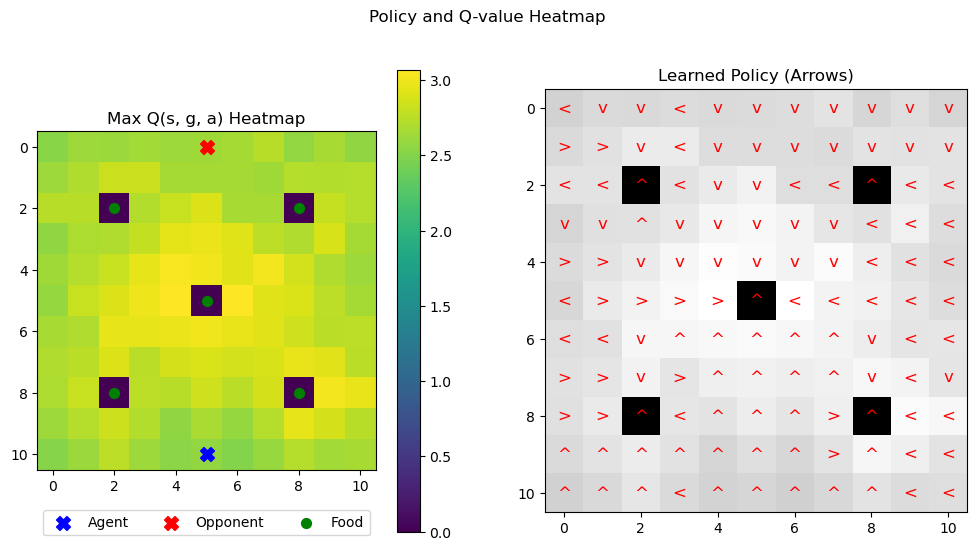

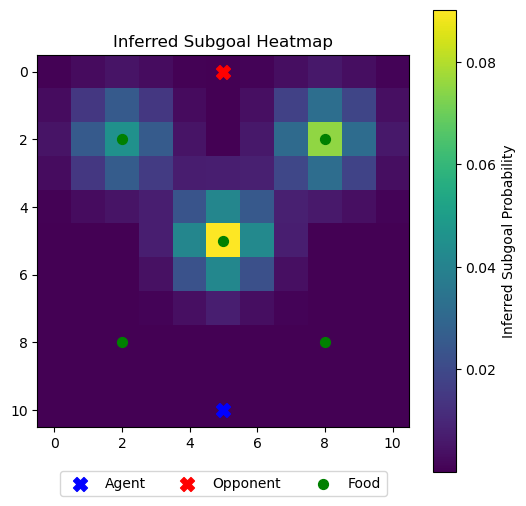

. . . . . B . . . . .
. . . . . . . . . . .
. . F . . . . . F . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . F . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . F . . . . . F . .
. . . . . . . . . . .
. . . . . A . . . . .

Step: 1 | Return: 0.0


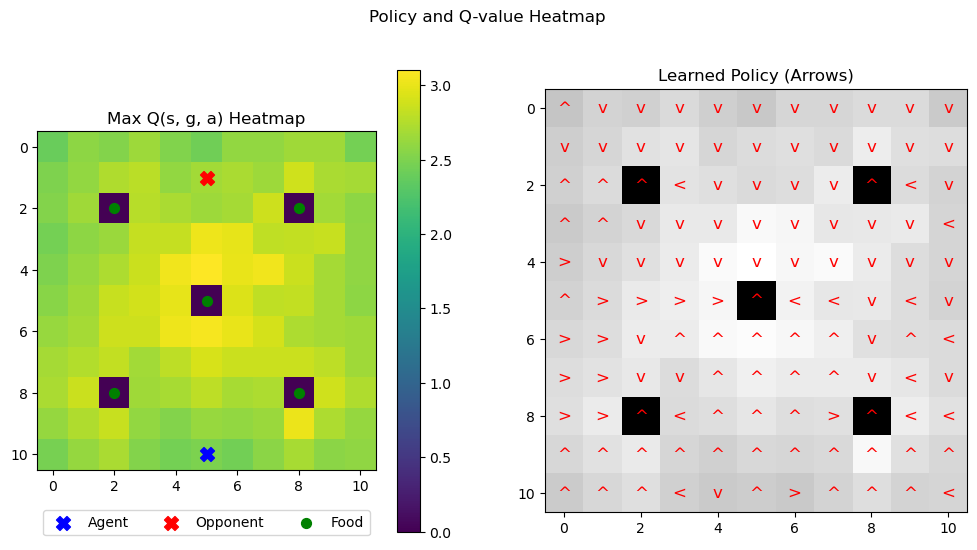

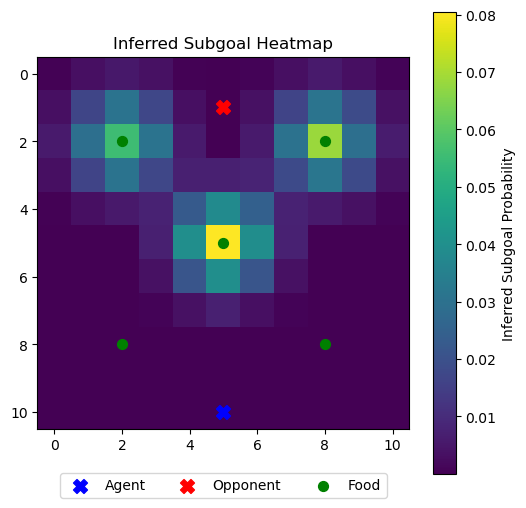

. . . . . . . . . . .
. . . . . B . . . . .
. . F . . . . . F . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . F . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . F . . . . . F . .
. . . . . . . . . . .
. . . . . A . . . . .

Step: 2 | Return: 0.0


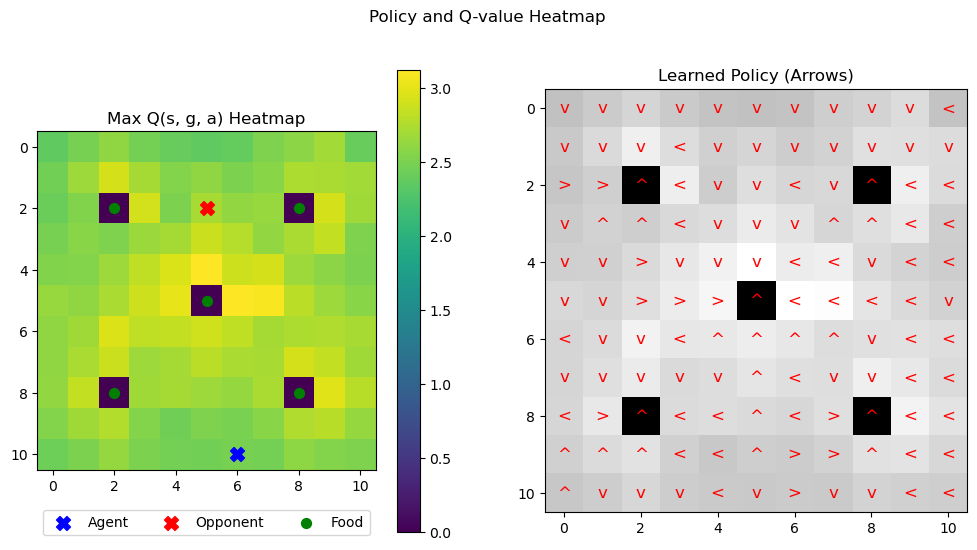

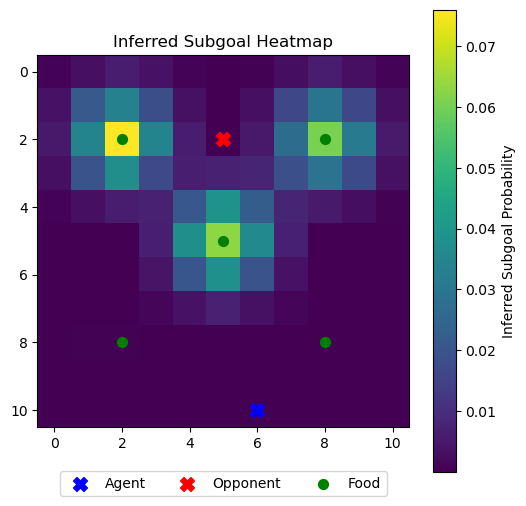

. . . . . . . . . . .
. . . . . . . . . . .
. . F . . B . . F . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . F . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . F . . . . . F . .
. . . . . . . . . . .
. . . . . . A . . . .

Step: 3 | Return: 0.0


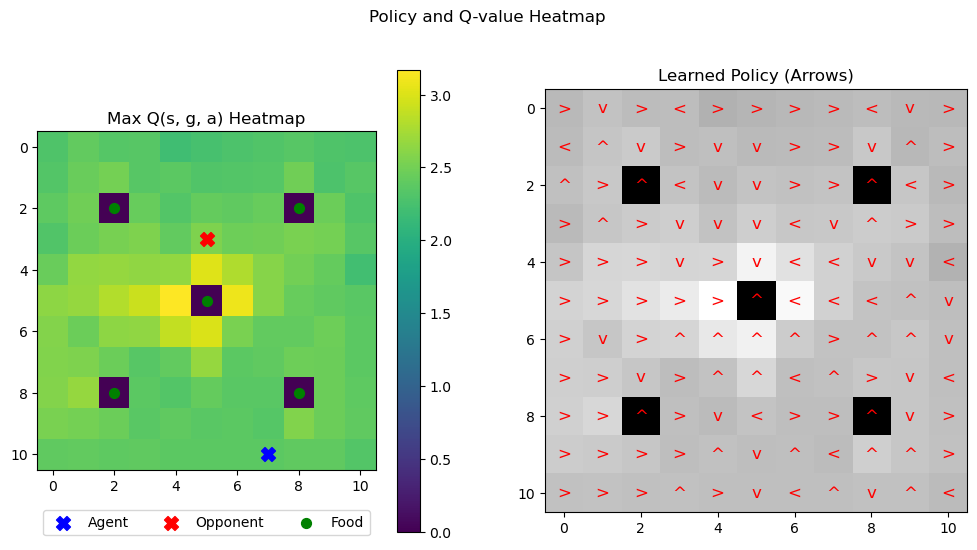

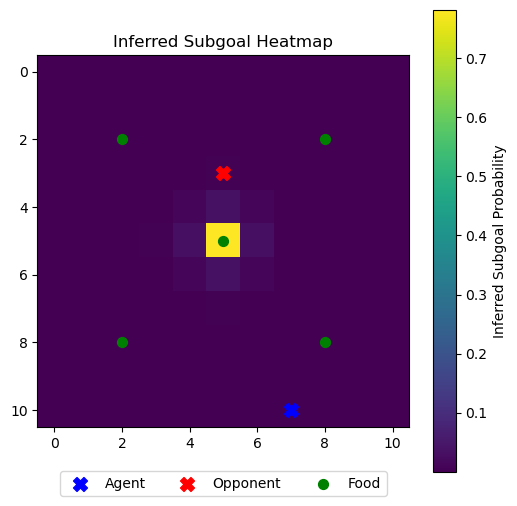

. . . . . . . . . . .
. . . . . . . . . . .
. . F . . . . . F . .
. . . . . B . . . . .
. . . . . . . . . . .
. . . . . F . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . F . . . . . F . .
. . . . . . . . . . .
. . . . . . . A . . .

Step: 4 | Return: 0.0


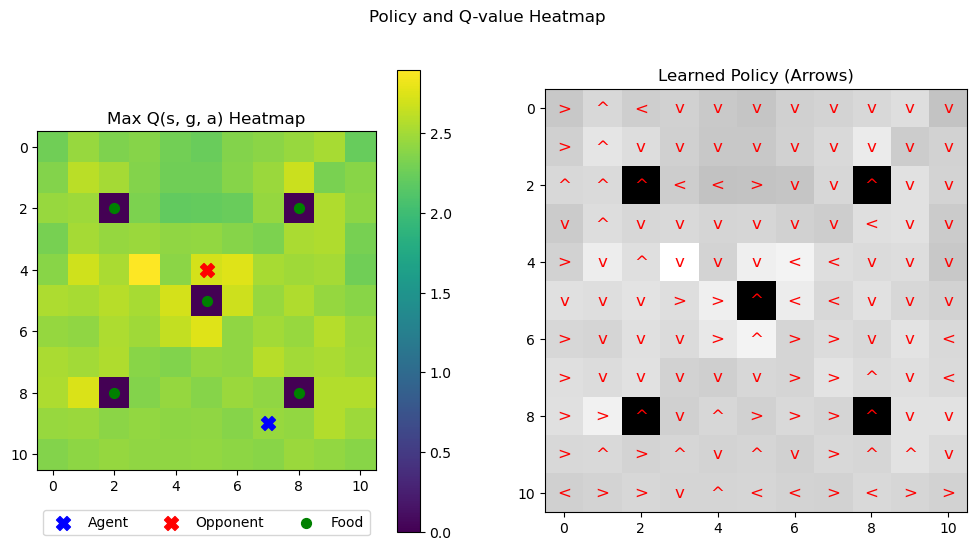

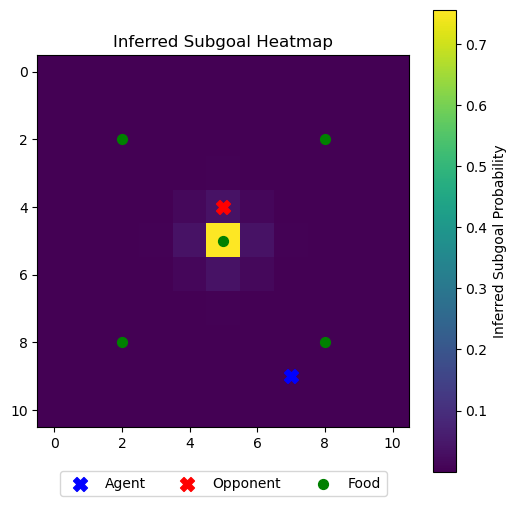

. . . . . . . . . . .
. . . . . . . . . . .
. . F . . . . . F . .
. . . . . . . . . . .
. . . . . B . . . . .
. . . . . F . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . F . . . . . F . .
. . . . . . . A . . .
. . . . . . . . . . .

Step: 5 | Return: 0.0


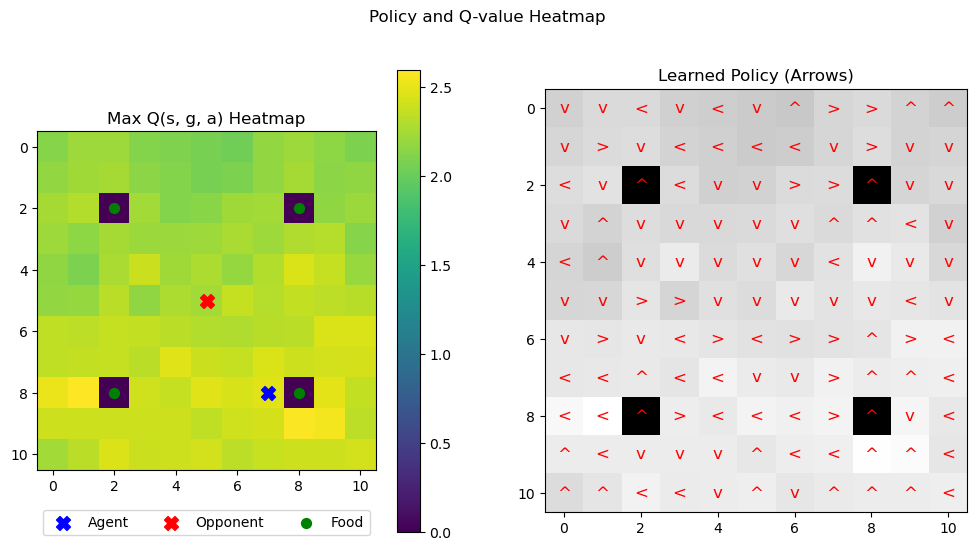

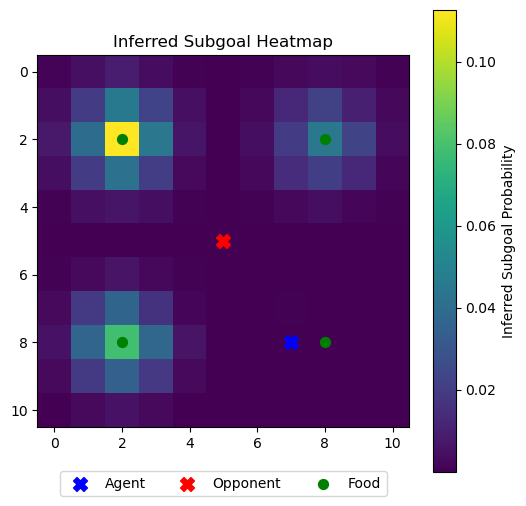

. . . . . . . . . . .
. . . . . . . . . . .
. . F . . . . . F . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . B . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . F . . . . A F . .
. . . . . . . . . . .
. . . . . . . . . . .

Step: 6 | Return: 1.0


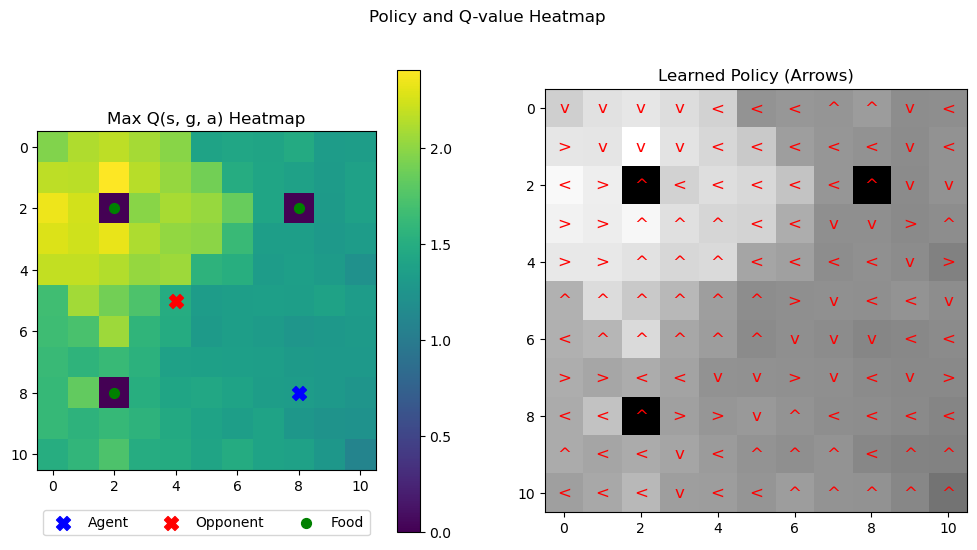

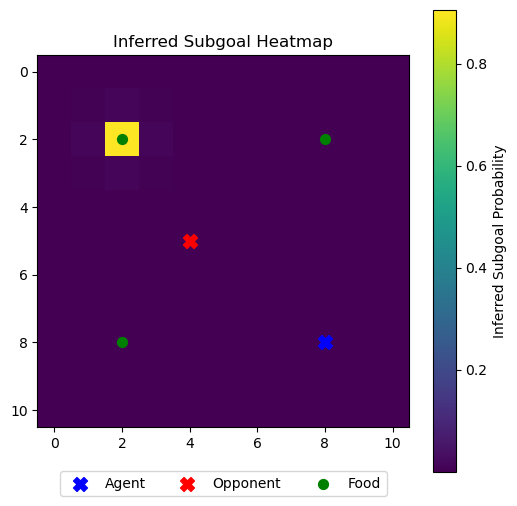

. . . . . . . . . . .
. . . . . . . . . . .
. . F . . . . . F . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . B . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . F . . . . . A . .
. . . . . . . . . . .
. . . . . . . . . . .

Step: 7 | Return: 1.0


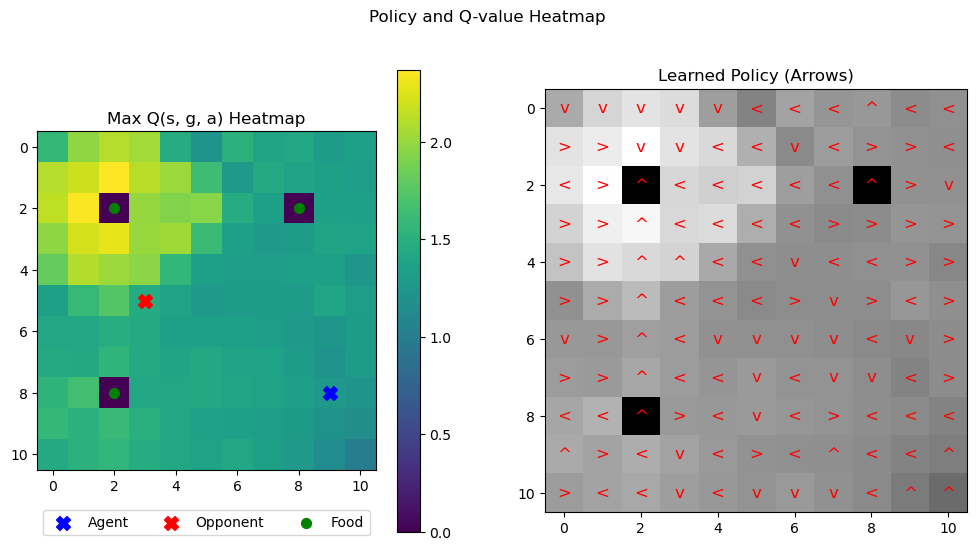

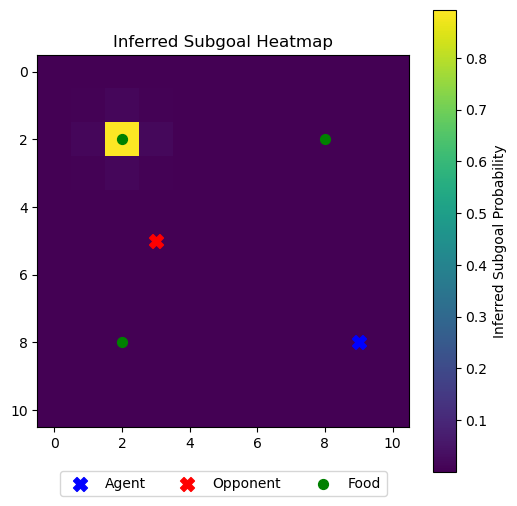

. . . . . . . . . . .
. . . . . . . . . . .
. . F . . . . . F . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . B . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . F . . . . . . A .
. . . . . . . . . . .
. . . . . . . . . . .

Step: 8 | Return: 1.0


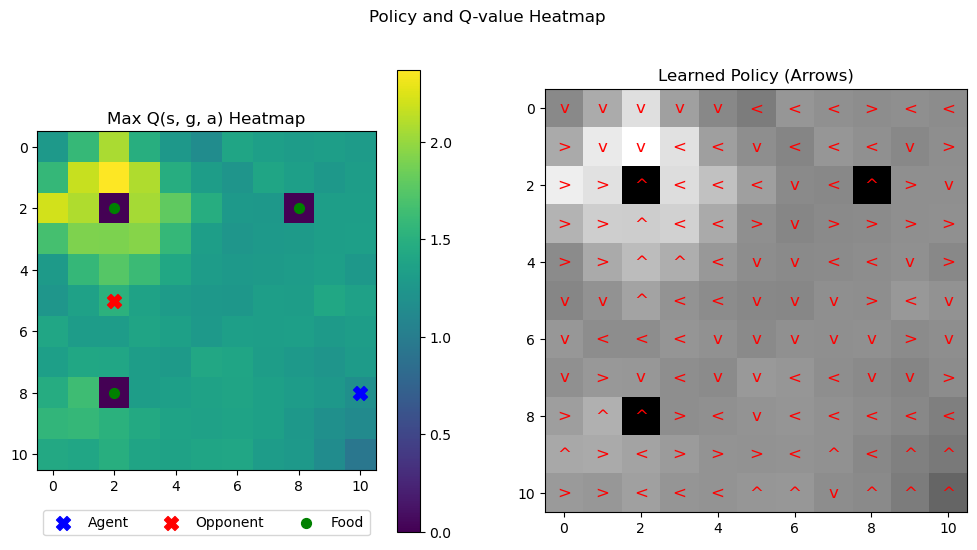

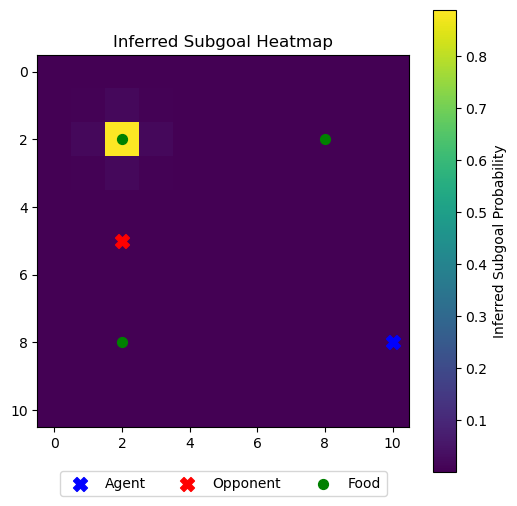

. . . . . . . . . . .
. . . . . . . . . . .
. . F . . . . . F . .
. . . . . . . . . . .
. . . . . . . . . . .
. . B . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . F . . . . . . . A
. . . . . . . . . . .
. . . . . . . . . . .

Step: 9 | Return: 1.0


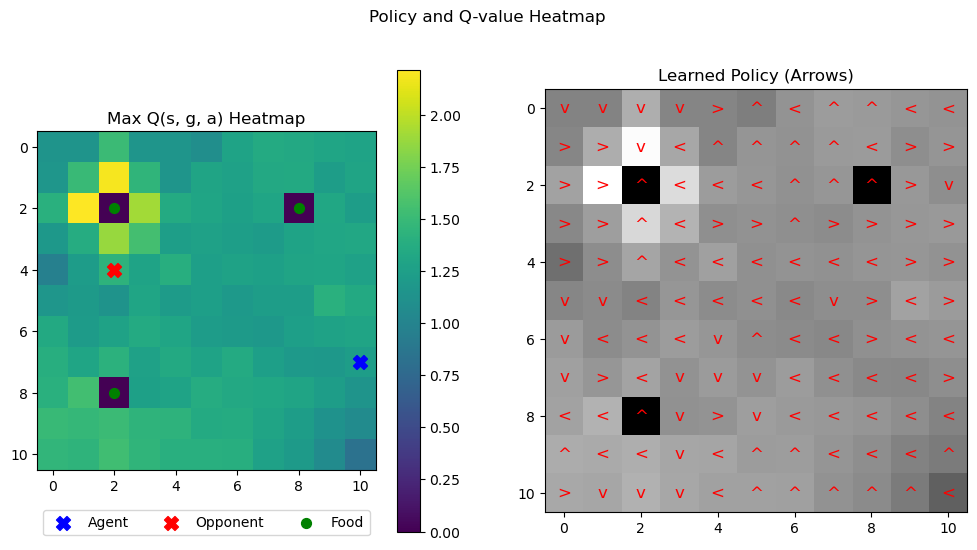

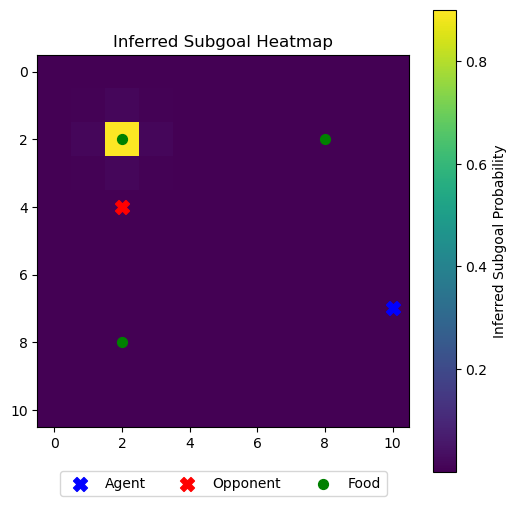

. . . . . . . . . . .
. . . . . . . . . . .
. . F . . . . . F . .
. . . . . . . . . . .
. . B . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . A
. . F . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .

Step: 10 | Return: 1.0


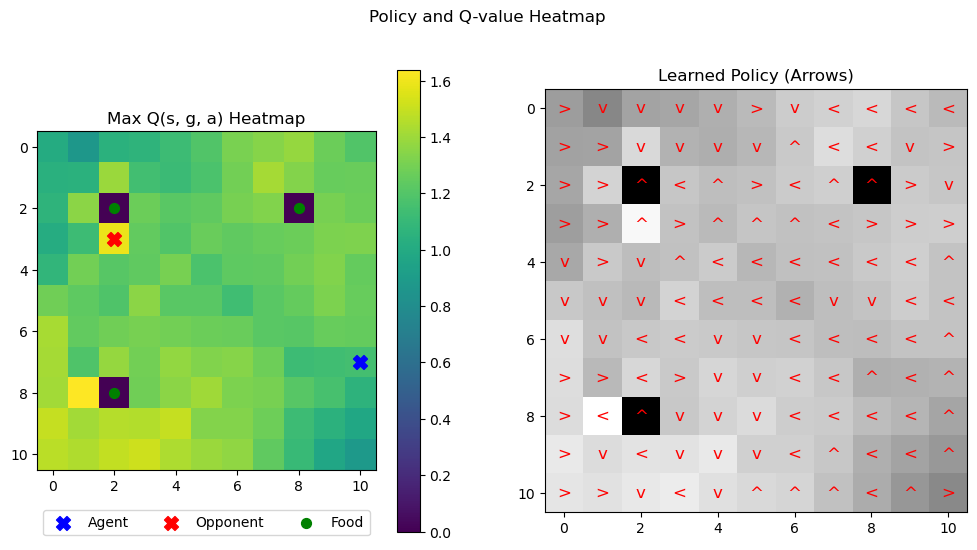

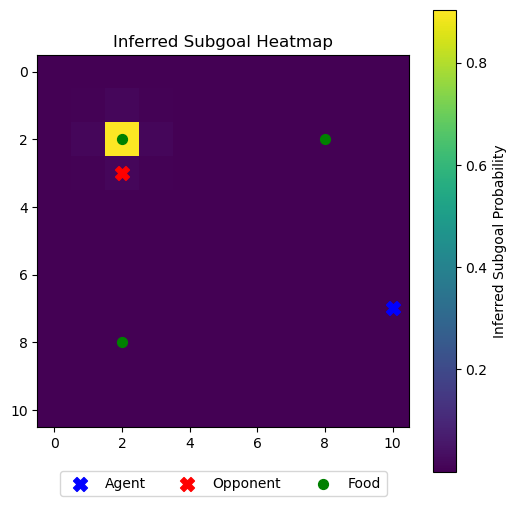

. . . . . . . . . . .
. . . . . . . . . . .
. . F . . . . . F . .
. . B . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . A
. . F . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .

Step: 11 | Return: 1.0


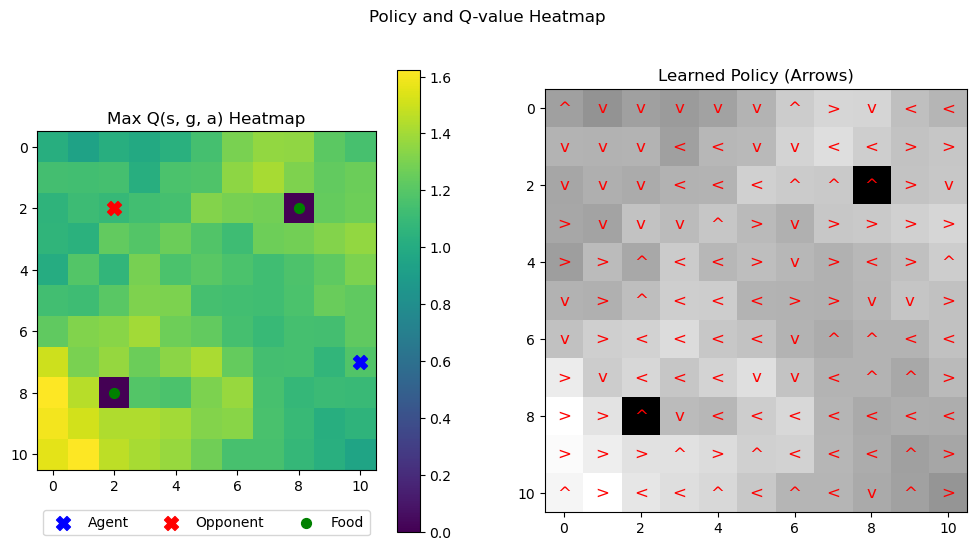

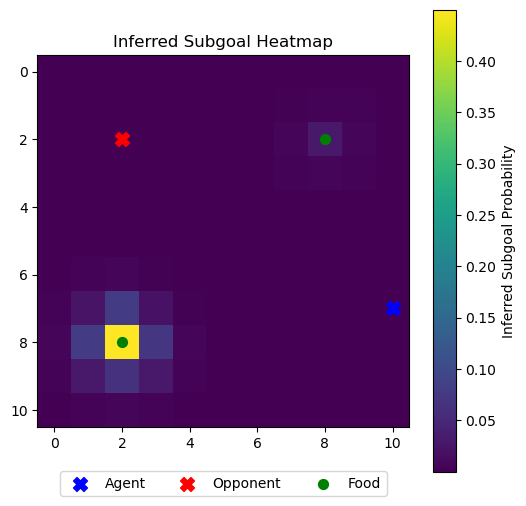

. . . . . . . . . . .
. . . . . . . . . . .
. . B . . . . . F . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . A
. . F . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .

Step: 12 | Return: 1.0


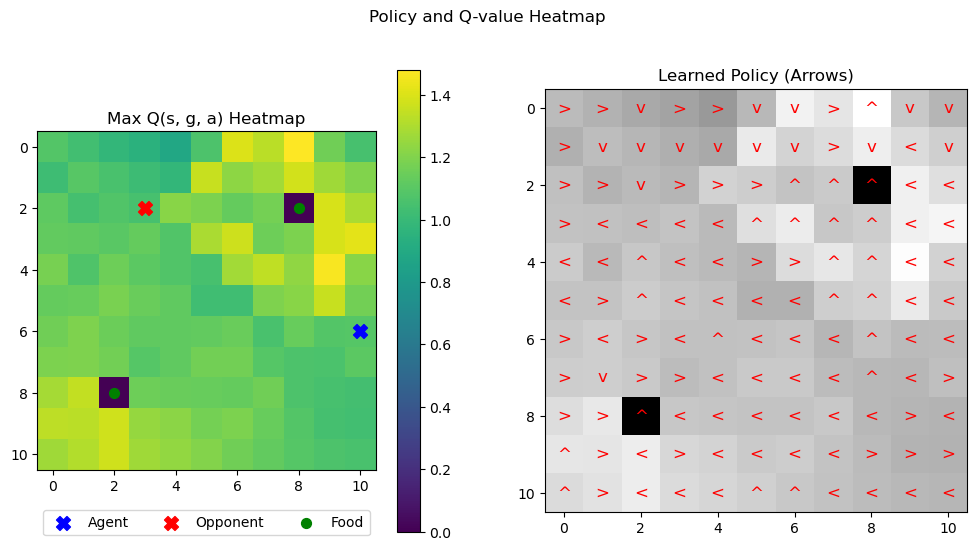

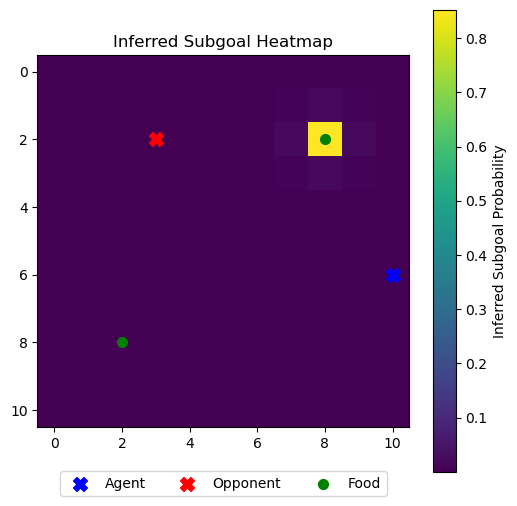

. . . . . . . . . . .
. . . . . . . . . . .
. . . B . . . . F . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . A
. . . . . . . . . . .
. . F . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .

Step: 13 | Return: 1.0


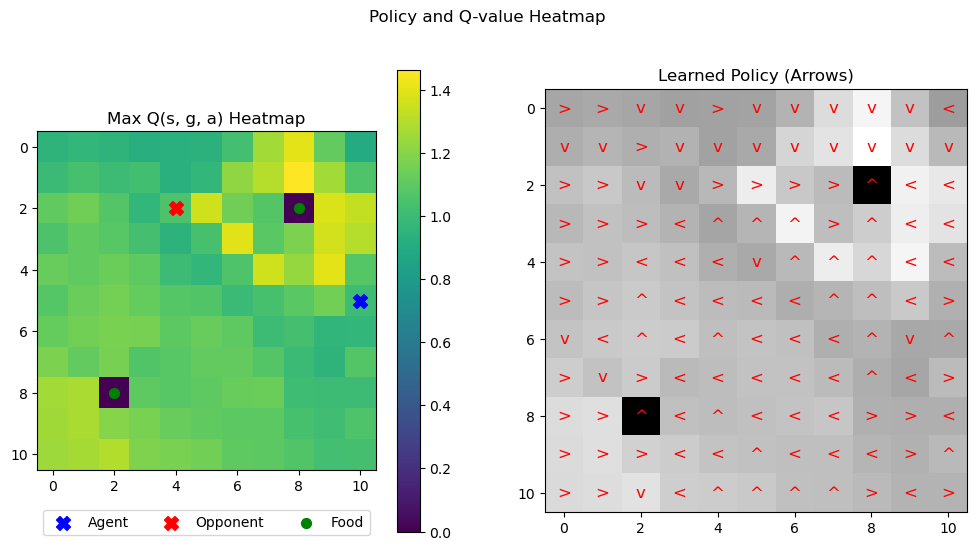

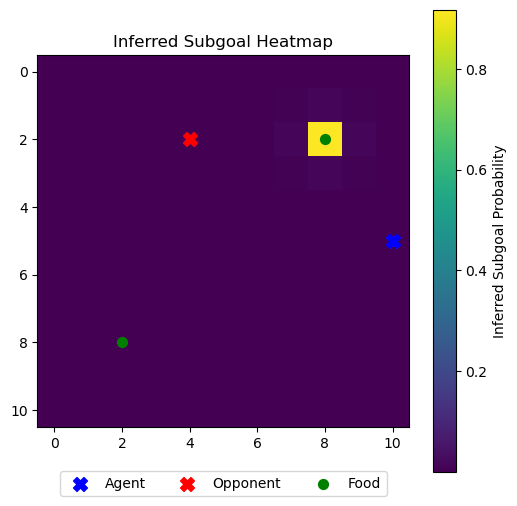

. . . . . . . . . . .
. . . . . . . . . . .
. . . . B . . . F . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . A
. . . . . . . . . . .
. . . . . . . . . . .
. . F . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .

Step: 14 | Return: 1.0


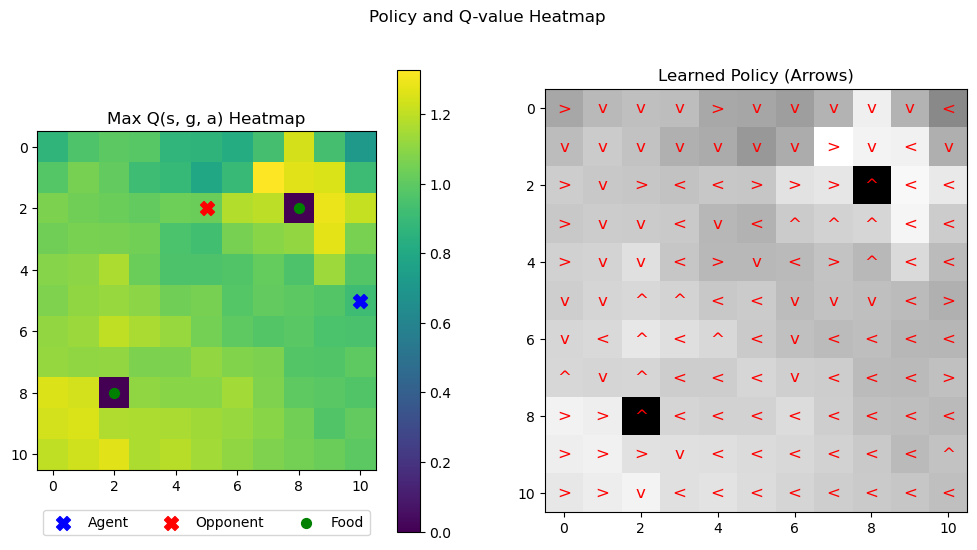

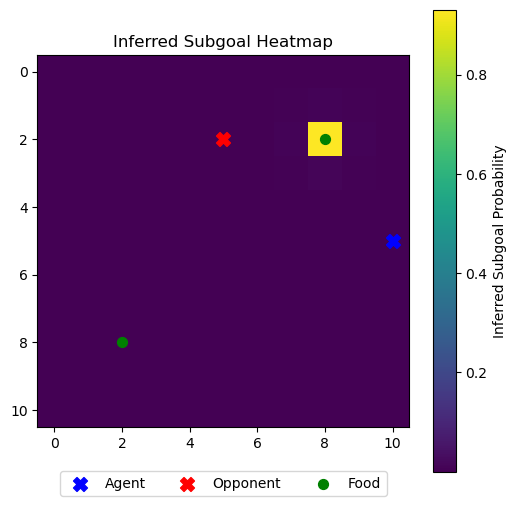

. . . . . . . . . . .
. . . . . . . . . . .
. . . . . B . . F . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . A
. . . . . . . . . . .
. . . . . . . . . . .
. . F . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .

Step: 15 | Return: 1.0


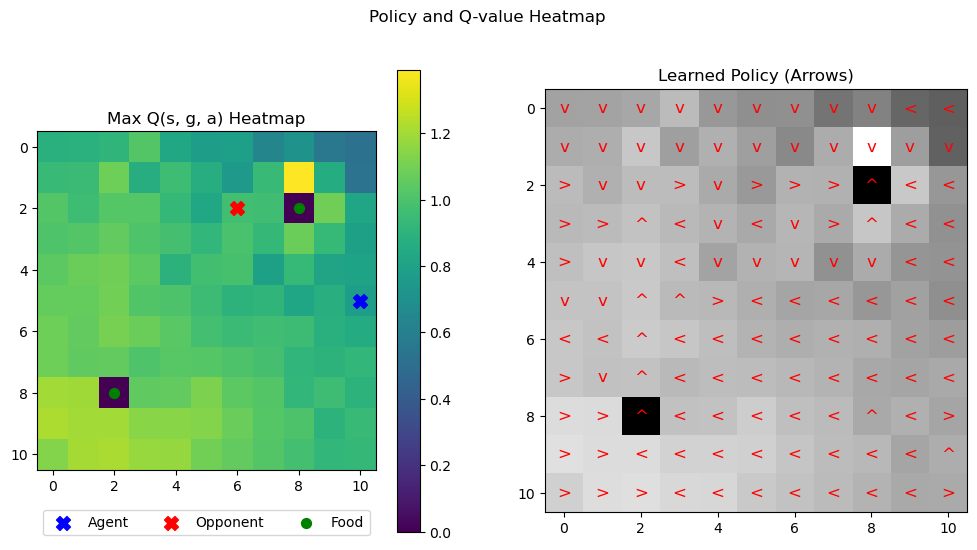

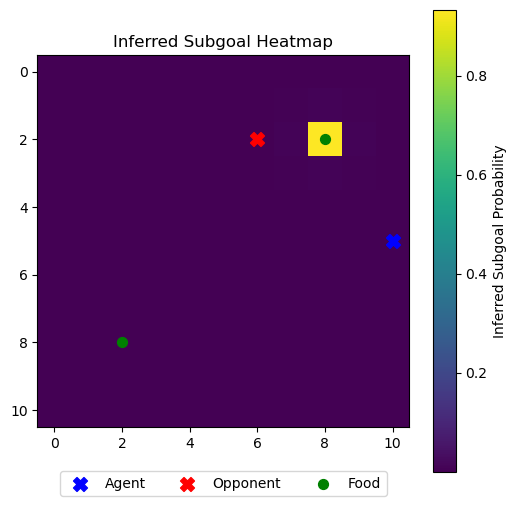

. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . B . F . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . A
. . . . . . . . . . .
. . . . . . . . . . .
. . F . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .

Step: 16 | Return: 1.0


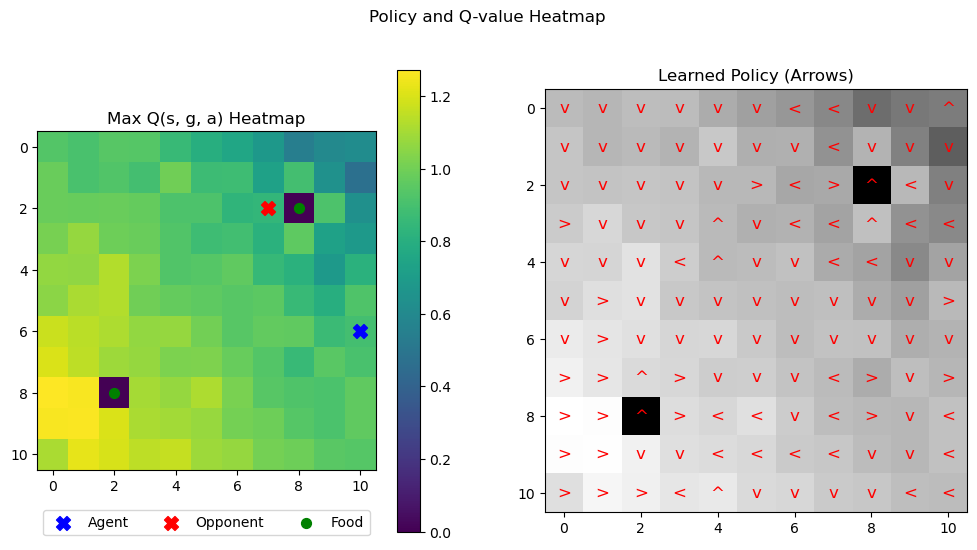

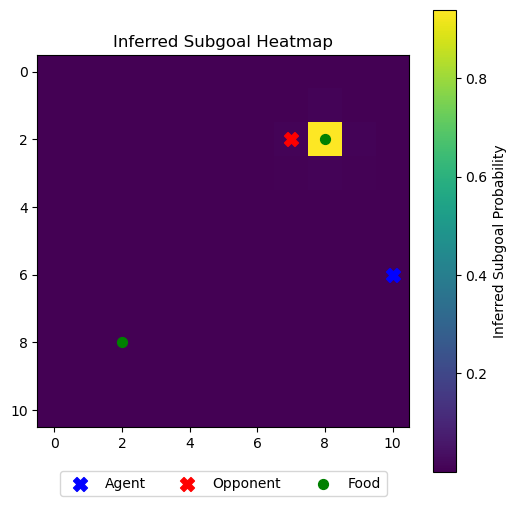

. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . B F . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . A
. . . . . . . . . . .
. . F . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .

Step: 17 | Return: 1.0


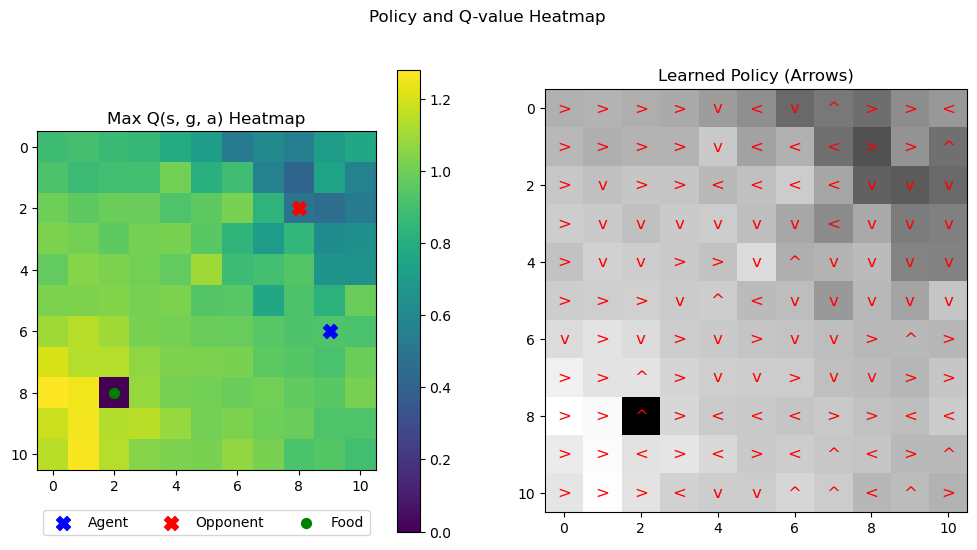

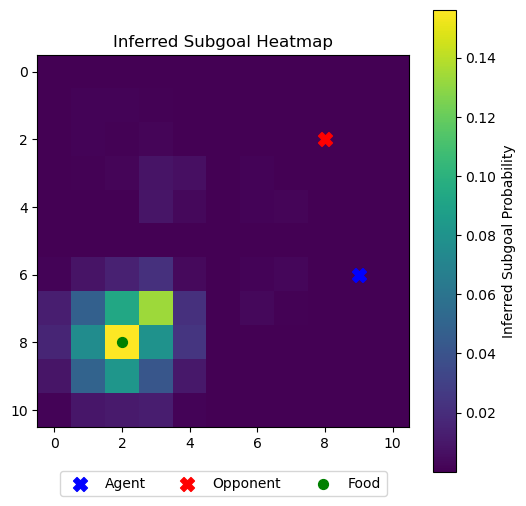

. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . B . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . A .
. . . . . . . . . . .
. . F . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .

Step: 18 | Return: 1.0


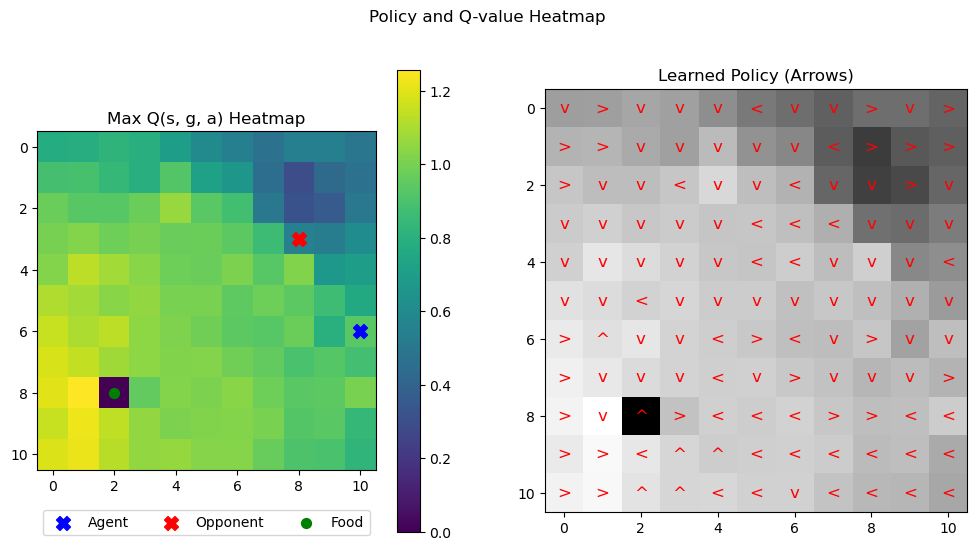

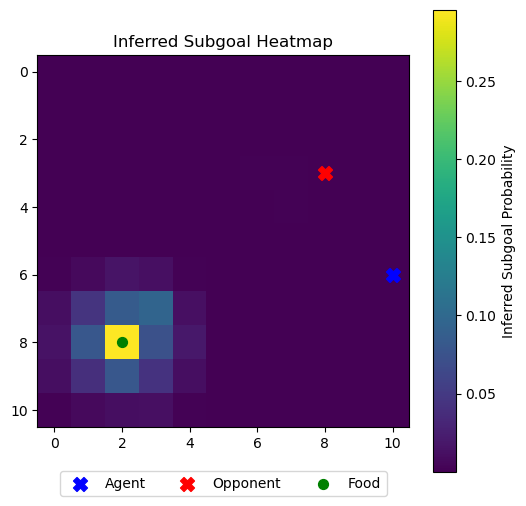

. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . B . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . A
. . . . . . . . . . .
. . F . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .

Step: 19 | Return: 1.0


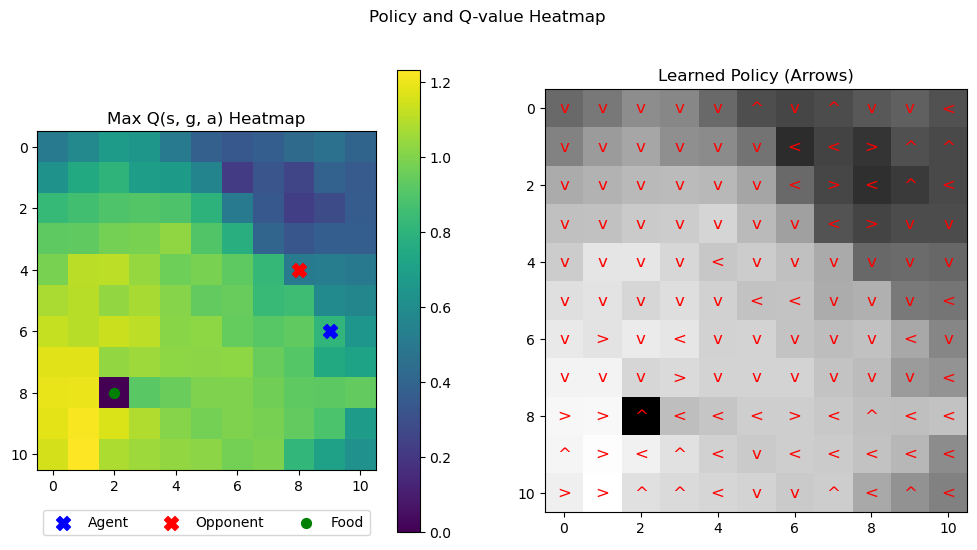

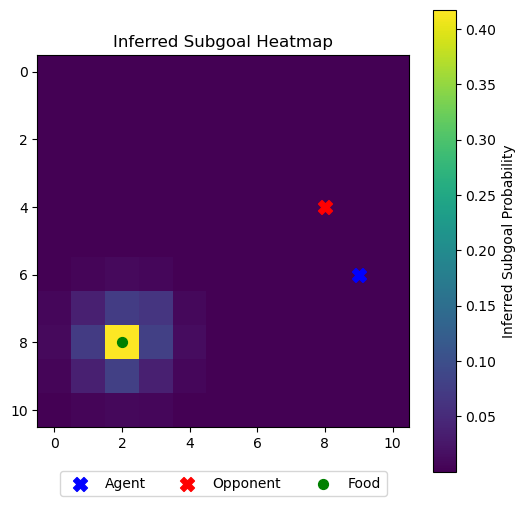

. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . B . .
. . . . . . . . . . .
. . . . . . . . . A .
. . . . . . . . . . .
. . F . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .

Step: 20 | Return: 1.0


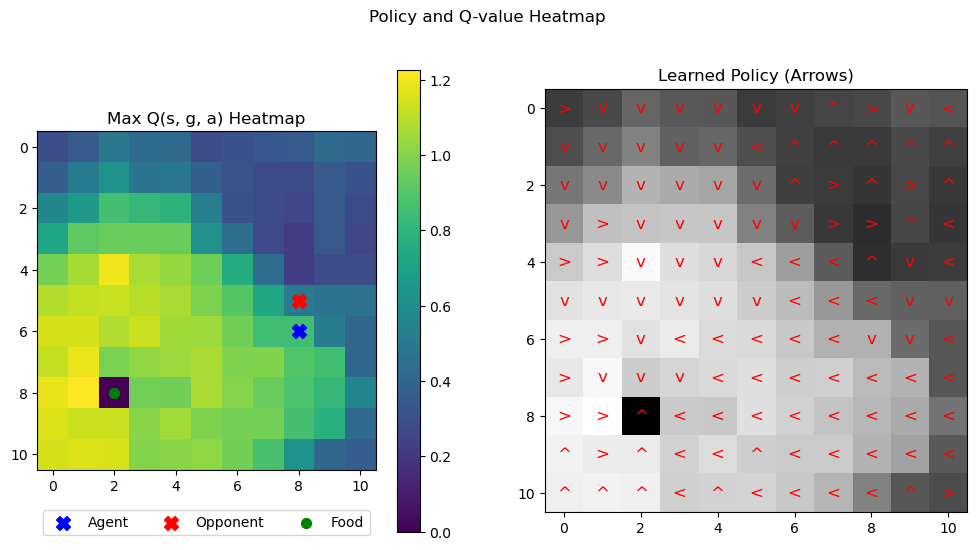

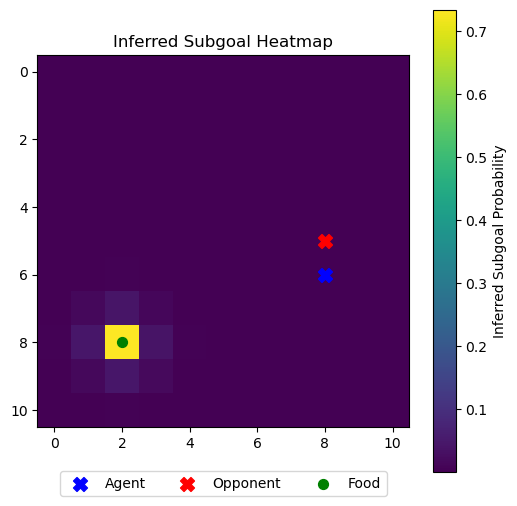

. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . B . .
. . . . . . . . A . .
. . . . . . . . . . .
. . F . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .

Step: 21 | Return: 1.0


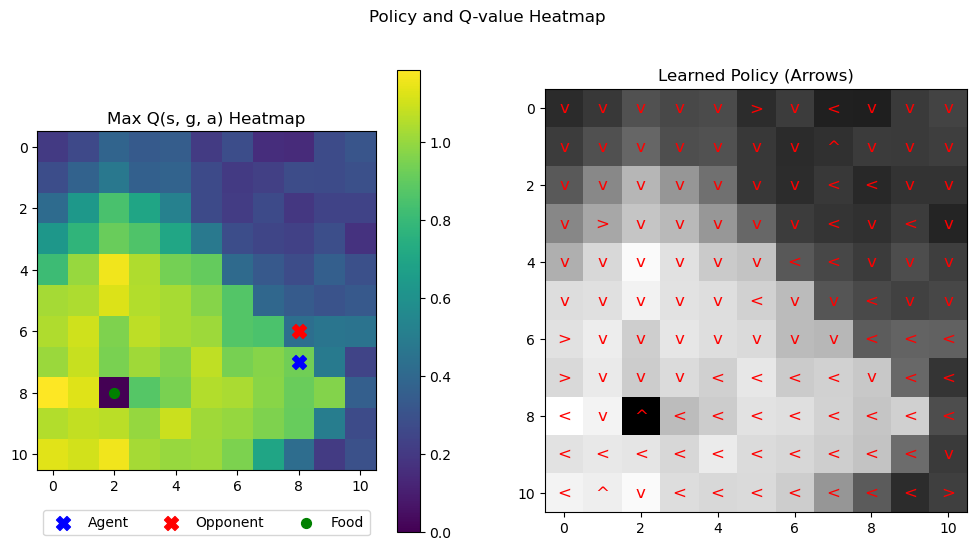

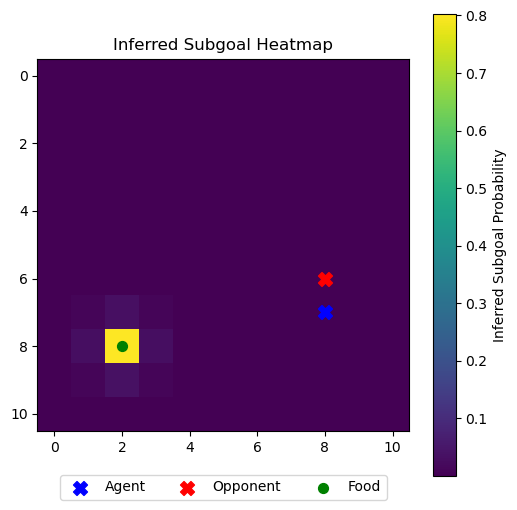

. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . B . .
. . . . . . . . A . .
. . F . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .

Step: 22 | Return: 1.0


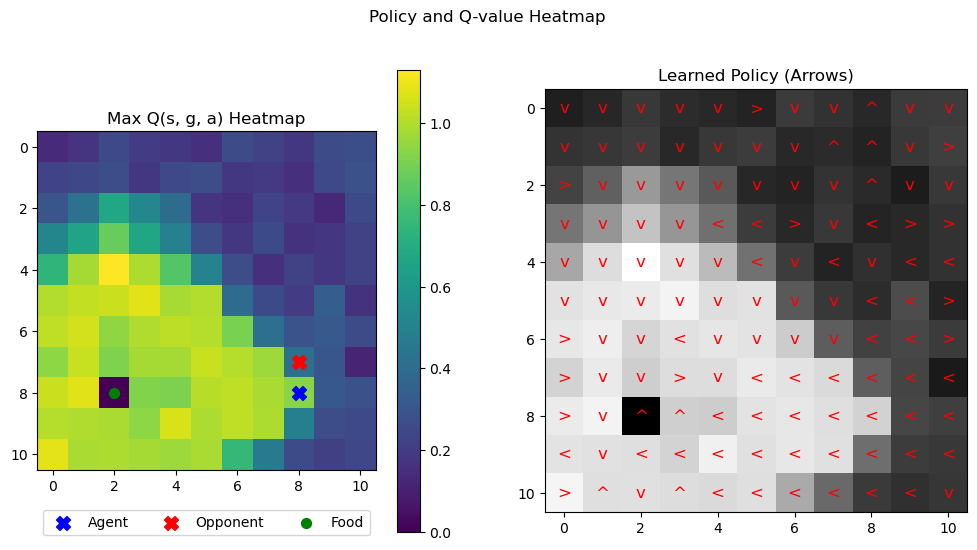

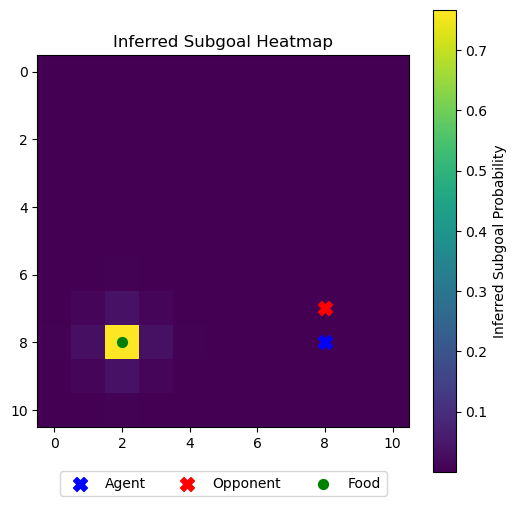

. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . B . .
. . F . . . . . A . .
. . . . . . . . . . .
. . . . . . . . . . .

Step: 23 | Return: 1.0


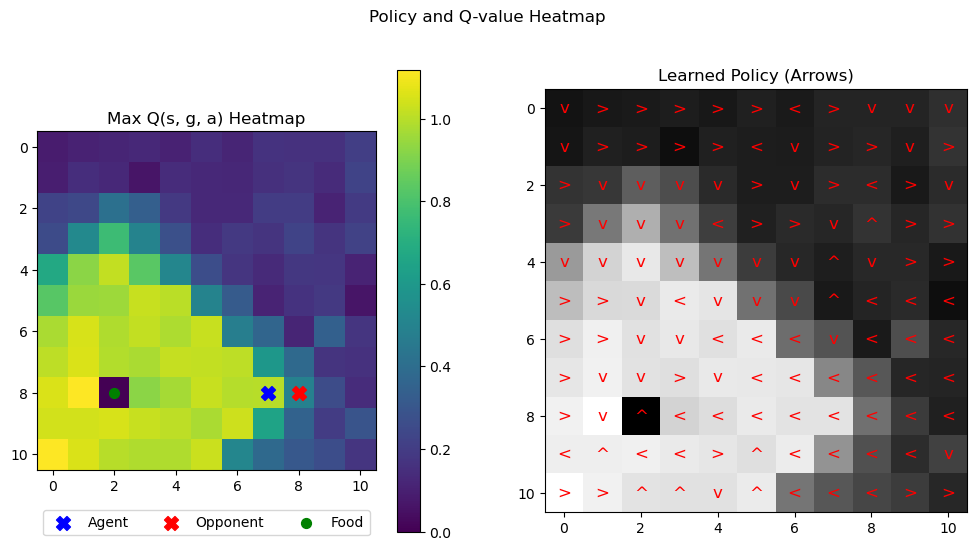

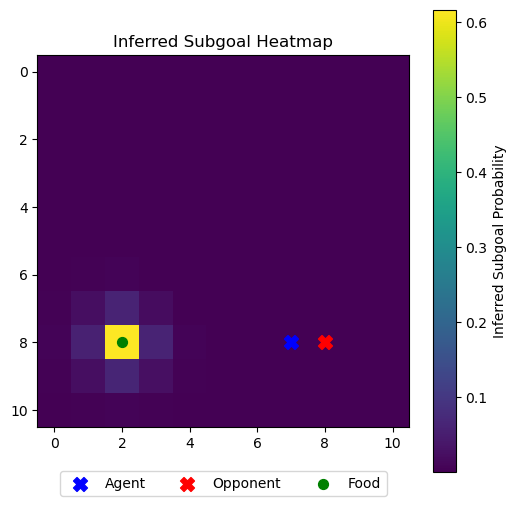

. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . F . . . . A B . .
. . . . . . . . . . .
. . . . . . . . . . .

Step: 24 | Return: 1.0


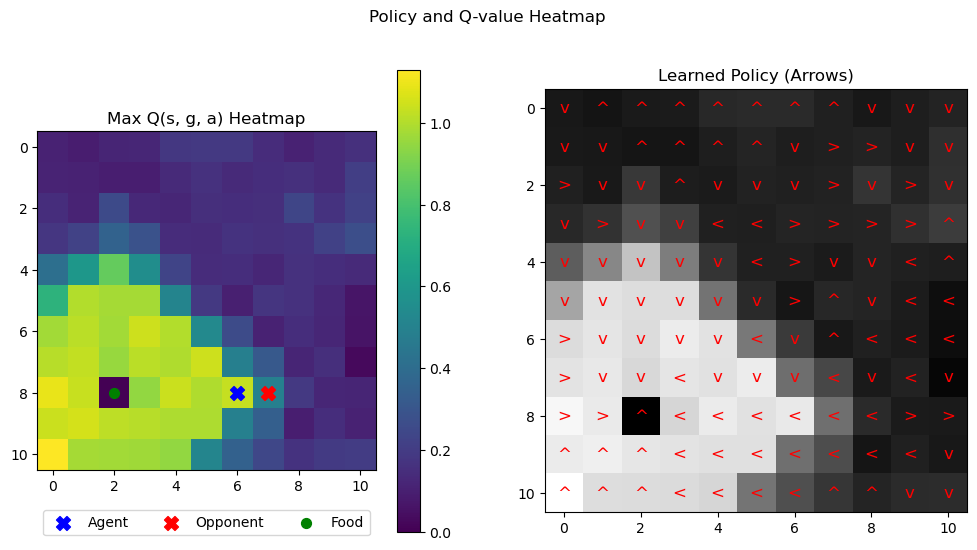

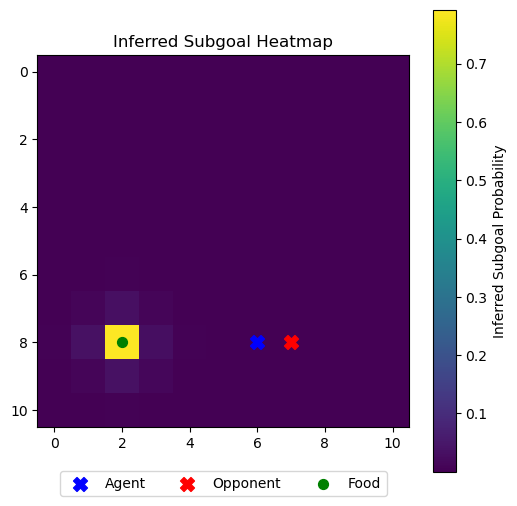

. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . F . . . A B . . .
. . . . . . . . . . .
. . . . . . . . . . .

Step: 25 | Return: 1.0


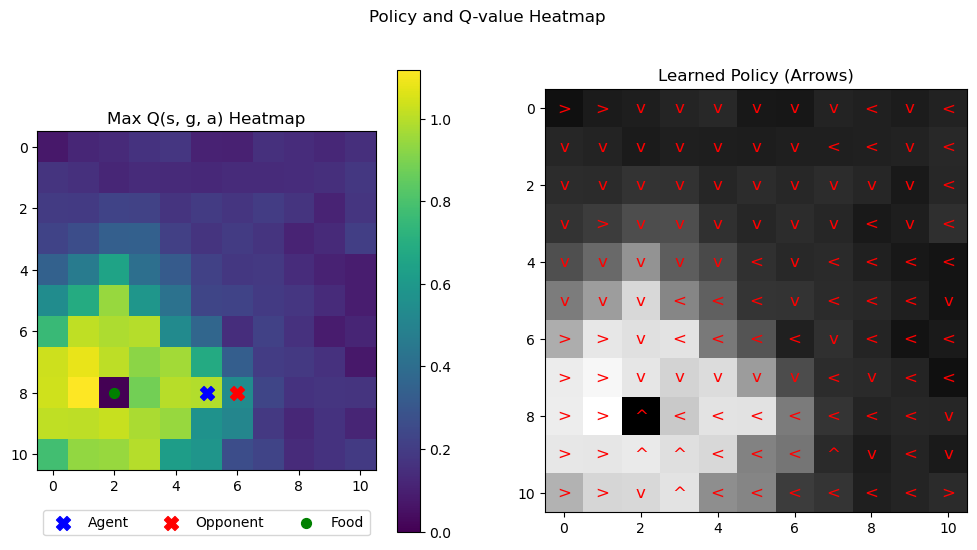

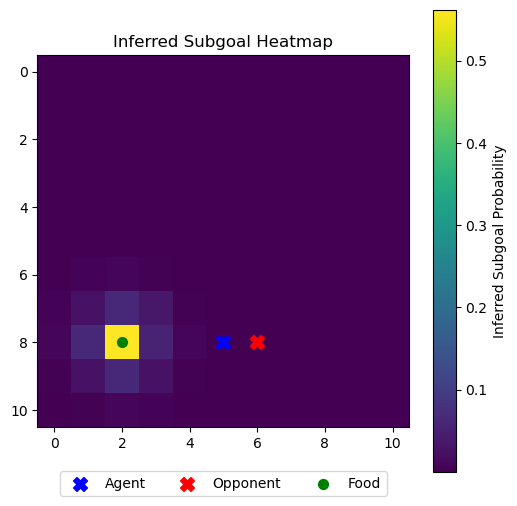

. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . F . . A B . . . .
. . . . . . . . . . .
. . . . . . . . . . .

Step: 26 | Return: 1.0


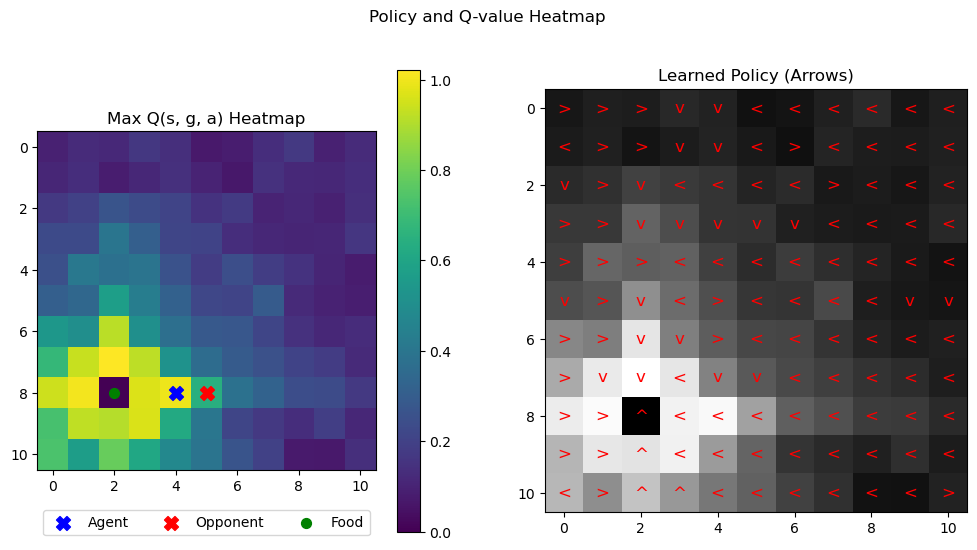

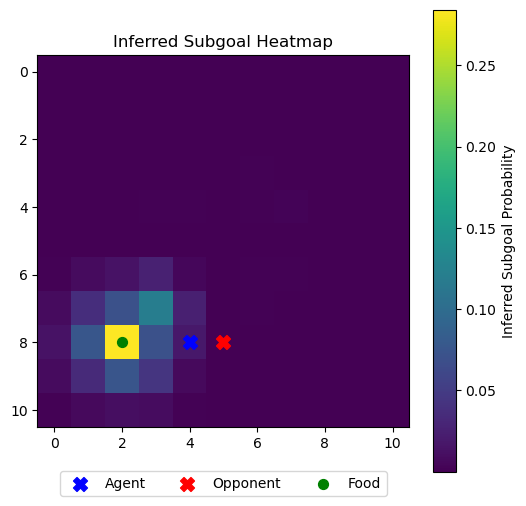

. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . F . A B . . . . .
. . . . . . . . . . .
. . . . . . . . . . .

Step: 27 | Return: 1.0


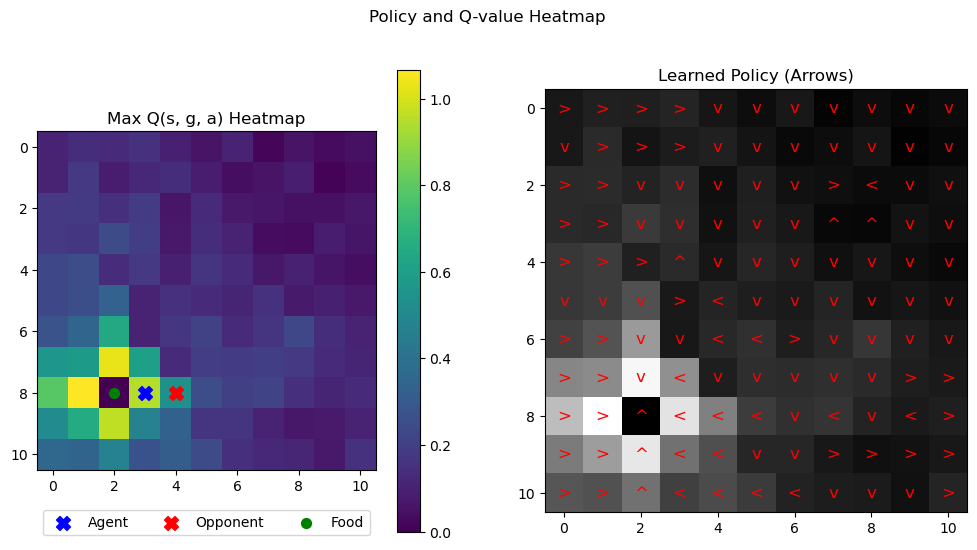

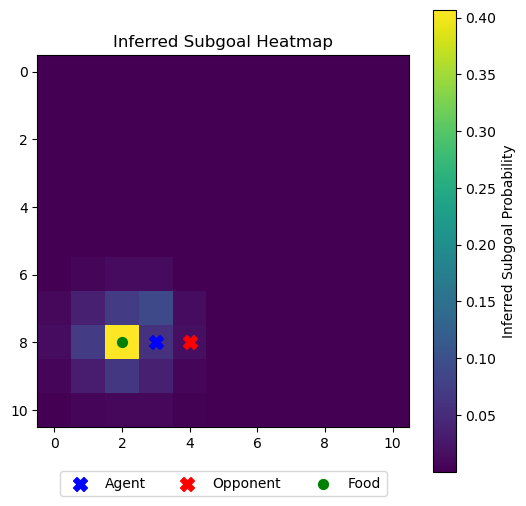

. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .
. . F A B . . . . . .
. . . . . . . . . . .
. . . . . . . . . . .



{'return': 2.0,
 'steps': 28,
 'opp_return': 3.0,
 'avg_entropy': 0.8283738700206597,
 'avg_kl_error': np.float64(3.93811315648696),
 'avg_spatial_error': np.float64(0.35294117647058826)}

In [12]:
run_om_episode(env, q_agent, opponent_agent, render=True)

In [ ]:
run_classic_episode(env, q_agent_classic, opponent_agent, render=True)

In [ ]:
q_agent.model.inference_model.visualize_action_embeddings()

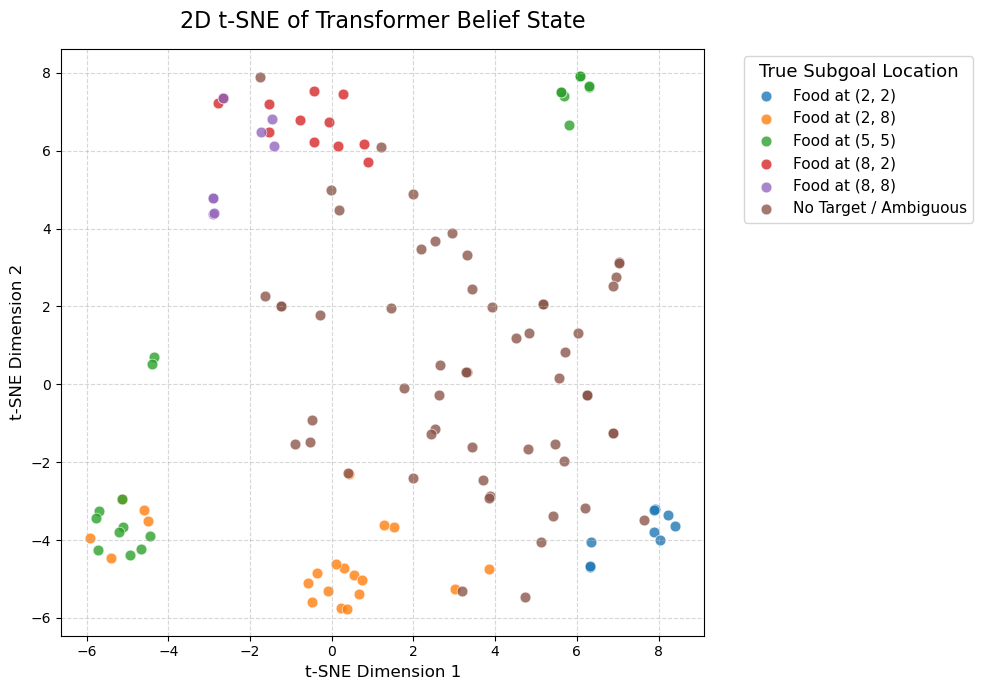

In [11]:
# dataset = torch.load(f"./dataset/dataset_map_3.pt", weights_only=False)

dataset = collect_data(env, q_agent, opponent_agent, num_episodes=100)


batch_data = random.sample(dataset, args.batch_size)


om_batch = {
  "states": torch.from_numpy(np.stack([b["state"] for b in batch_data], dtype=np.float32)).to(device, non_blocking=True),
  "history": {
            "state_features": torch.from_numpy(np.array([b["history"]["state_features"][0] for b in batch_data], dtype=np.float32)).to(device),
            "actions": torch.from_numpy(np.array([b["history"]["actions"][0] for b in batch_data], dtype=np.int64)).to(device),
            "mask": torch.from_numpy(np.array([b["history"]["mask"][0] for b in batch_data], dtype=np.bool_)).to(device)
        },
  "true_goal_map": torch.from_numpy(np.stack([b["true_goal_map"] for b in batch_data], dtype=np.float32)).to(device, non_blocking=True),
  # "true_opp_heatmap": torch.from_numpy(np.stack([b["true_opp_heatmap"] for b in batch_data], dtype=np.float32)).to(device, non_blocking=True),
}
x = om_batch['states']
history = om_batch['history']
target_map = om_batch['true_goal_map']

visualize_final_memory_2d(q_agent.model.inference_model, x, history, target_map)
visualize_final_memory_3d(q_agent.model.inference_model, x, history, target_map)